<img src="https://res.cloudinary.com/dtizipxds/image/upload/q_auto/f_auto/v1776264397/banner_yvwajv.png" width="100%">


In [1]:
%pip install numpy pandas matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


# Classification Workshop

Classification is a supervised learning task where the goal is to predict a **discrete label** (for example: benign vs malignant).

In this notebook, we will:
1. Load a built-in classification dataset.
2. Run quick EDA (head, nulls, duplicates, correlations, visualizations).
3. Preprocess the data (split, impute, scale).
4. Train and evaluate multiple models:
   - Decision Tree and Random Forest
   - K-Nearest Neighbors (with elbow-style search for `k`)
   - Naive Bayes
   - Bonus: Logistic Regression and SVM
5. Compare all models at the end.


In [2]:
# Imports and setup
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

sns.set_theme(style="whitegrid")
np.random.seed(42)

In [3]:
# Load a classification dataset (Breast Cancer Wisconsin)
dataset = load_breast_cancer(as_frame=True)
df = dataset.frame.copy()

# Rename target for readability
df = df.rename(columns={"target": "diagnosis"})

print("Shape:", df.shape)
print("Target classes:", dataset.target_names)

Shape: (569, 31)
Target classes: ['malignant' 'benign']


## Quick Dataset Introduction

The dataset contains numeric features computed from digitized breast mass images.

- **Target**: `diagnosis`
  - `0` -> malignant
  - `1` -> benign
- Features include radius, texture, perimeter, area, smoothness, and more.

This is a good starter dataset because it is clean, numeric, and commonly used for binary classification demos.



## Column Guide (Simple Explanations)

Feature names follow this pattern:

- **`mean ...`**: average value across the nucleus measurements  
- **`... error`**: variation/uncertainty (standard error)  
- **`worst ...`**: largest (worst-case) value observed  

<details>
<summary><strong>diagnosis</strong></summary>

Target label:
- **0 = malignant**
- **1 = benign**

</details>

<details>
<summary><strong>radius</strong></summary>

Average distance from the center to points on the perimeter.

</details>

<details>
<summary><strong>texture</strong></summary>

How much gray-level intensity varies (surface visual variation).

</details>

<details>
<summary><strong>perimeter</strong></summary>

Total length around the nucleus boundary.

</details>

<details>
<summary><strong>area</strong></summary>

Size of the nucleus surface area.

</details>

<details>
<summary><strong>smoothness</strong></summary>

How smooth the boundary is (less local variation = smoother edge).

</details>

<details>
<summary><strong>compactness</strong></summary>

How tightly packed the shape is, based on perimeter and area.

</details>

<details>
<summary><strong>concavity</strong></summary>

How deep/strong inward curves are in the boundary.

</details>

<details>
<summary><strong>concave points</strong></summary>

How many (or how strong) inward-pointing boundary sections exist.

</details>

<details>
<summary><strong>symmetry</strong></summary>

How balanced the shape is from one side to another.

</details>

<details>
<summary><strong>fractal dimension</strong></summary>

How irregular/complex the boundary is (coastline-like complexity).

</details>


In [4]:
# Basic inspection
df.head()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [5]:
# Null values, duplicates, and data summary
print("\nData types:")
print(df.dtypes.value_counts())

print("\nNull values per column (top 10):")
print(df.isnull().sum().sort_values(ascending=False).head(10))

print("\nNumber of duplicated rows:", df.duplicated().sum())

print("\nTarget distribution:")
print(df["diagnosis"].value_counts(normalize=True).rename("ratio"))



Data types:
float64    30
int32       1
Name: count, dtype: int64

Null values per column (top 10):
mean radius                0
concavity error            0
worst fractal dimension    0
worst symmetry             0
worst concave points       0
worst concavity            0
worst compactness          0
worst smoothness           0
worst area                 0
worst perimeter            0
dtype: int64

Number of duplicated rows: 0

Target distribution:
diagnosis
1    0.627417
0    0.372583
Name: ratio, dtype: float64


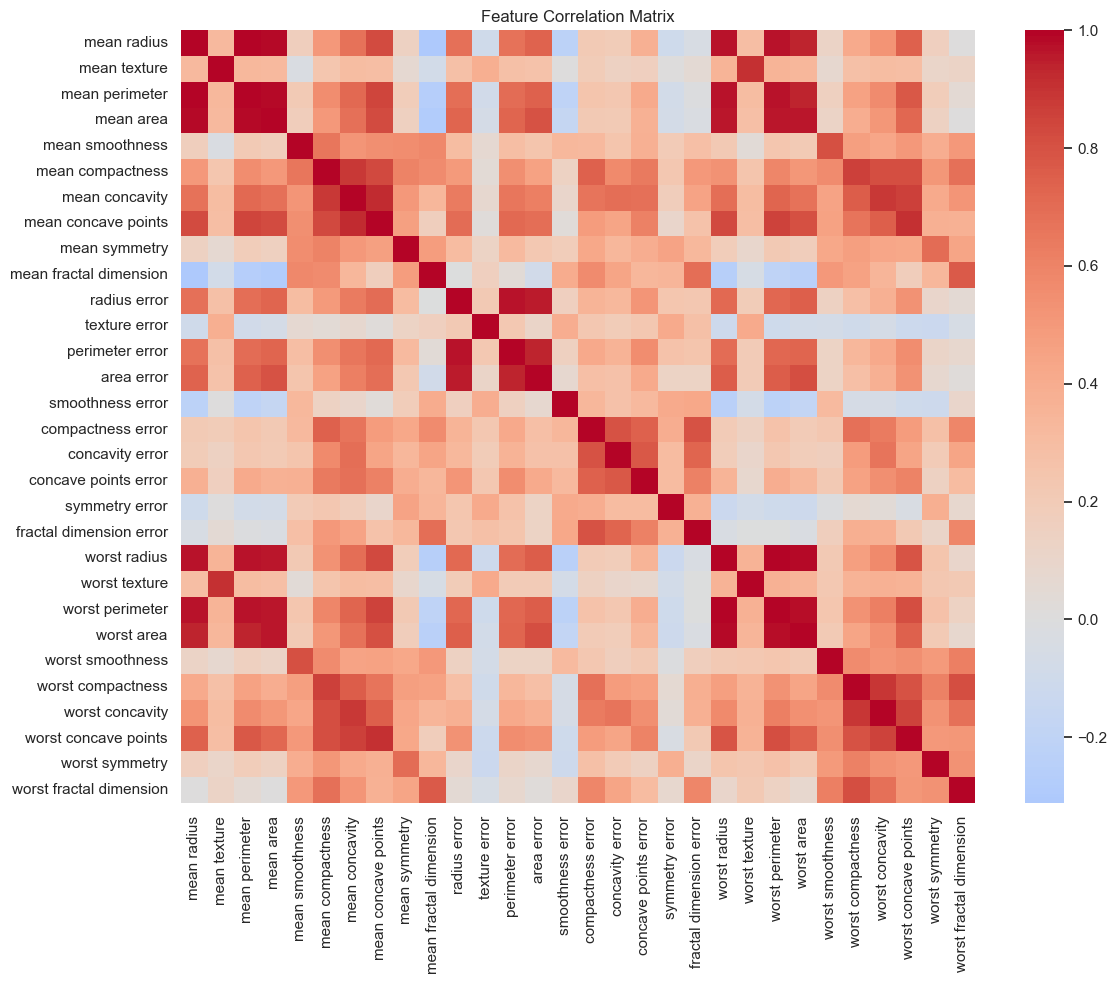

In [6]:
# Correlation matrix (features only)
plt.figure(figsize=(12, 10))
corr = df.drop(columns="diagnosis").corr()
sns.heatmap(corr, cmap="coolwarm", center=0, square=False)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()


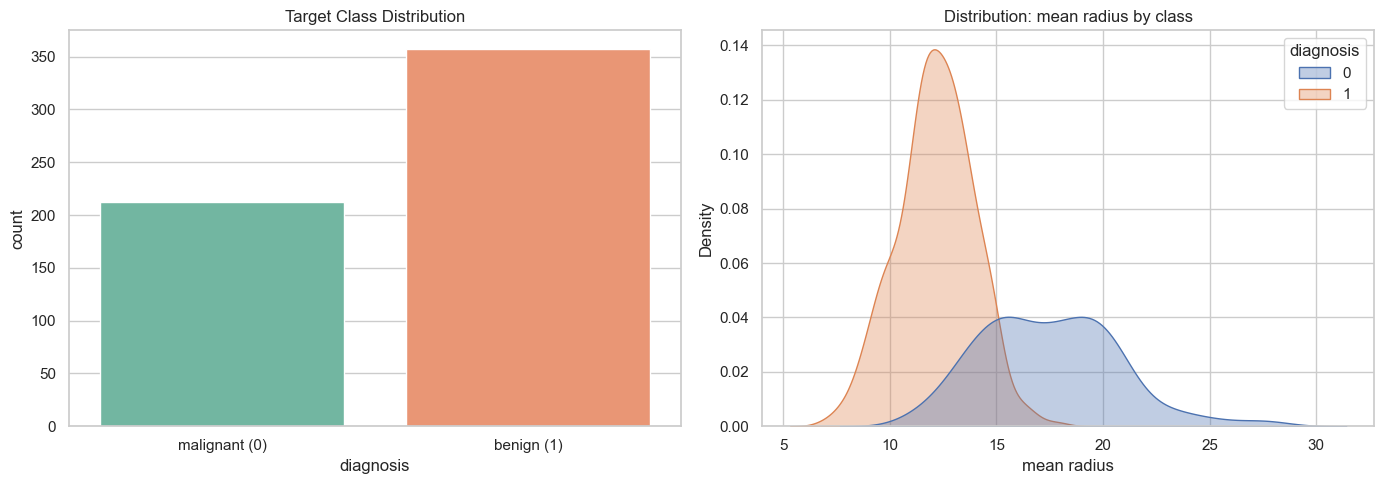

In [7]:
# A few quick visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x="diagnosis", ax=axes[0], palette="Set2")
axes[0].set_title("Target Class Distribution")
axes[0].set_xticklabels(["malignant (0)", "benign (1)"])

# Plot distributions for two representative features
sns.kdeplot(data=df, x="mean radius", hue="diagnosis", fill=True, alpha=0.35, ax=axes[1])
axes[1].set_title("Distribution: mean radius by class")

plt.tight_layout()
plt.show()


## Preprocessing

Even when a dataset is mostly clean, we build a reusable preprocessing flow:
- Split train/test with stratification.
- Impute missing values (median strategy).
- Scale features for distance/probability-based models (KNN, Naive Bayes).

Tree-based models are less sensitive to feature scaling, so they will use imputed (unscaled) data.


In [8]:
# Split features and target
X = df.drop(columns="diagnosis")
y = df["diagnosis"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Impute (for robustness)
imputer = SimpleImputer(strategy="median")
X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)

# Scale (important for KNN and helpful for NB)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled = scaler.transform(X_test_imp)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (455, 30)
Test shape: (114, 30)


In [9]:
# Helper for consistent evaluation
results = []

def evaluate_model(name, model, X_tr, X_te):
    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)

    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
    }
    results.append(metrics)
    return pd.Series(metrics)


## Tree-Based Models (Decision Tree, Random Forest)

- **Decision Tree**: splits the feature space with simple rules; very interpretable but can overfit.
- **Random Forest**: an ensemble of many trees trained on bootstrap samples; usually more stable and accurate.


In [10]:
# Decision Tree
dt = DecisionTreeClassifier(random_state=42, max_depth=4)
print("Decision Tree metrics:")
print(evaluate_model("Decision Tree", dt, X_train_imp, X_test_imp))

print("\n" + "-" * 60 + "\n")

# Random Forest
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    max_depth=None,
    min_samples_split=2,
)
print("Random Forest metrics:")
print(evaluate_model("Random Forest", rf, X_train_imp, X_test_imp))


Decision Tree metrics:
Model        Decision Tree
Accuracy          0.938596
Precision         0.957746
Recall            0.944444
F1                0.951049
dtype: object

------------------------------------------------------------

Random Forest metrics:
Model        Random Forest
Accuracy          0.947368
Precision         0.958333
Recall            0.958333
F1                0.958333
dtype: object


## K-Nearest Neighbors (KNN)

KNN predicts the class of a sample using the majority class among its `k` nearest neighbors.
Because distance drives this model, **feature scaling is essential**.

We use an elbow-style search over different `k` values to pick a good neighborhood size.


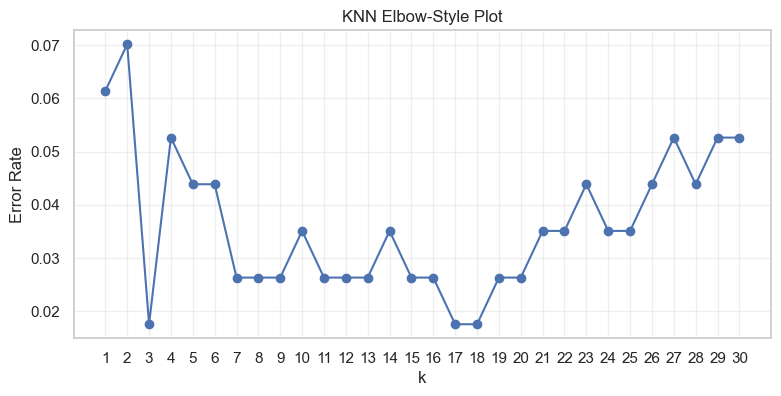

Chosen k (minimum error): 3


In [11]:
# Elbow-style search for k
k_values = list(range(1, 31))
error_rates = []

for k in k_values:
    knn_tmp = KNeighborsClassifier(n_neighbors=k)
    knn_tmp.fit(X_train_scaled, y_train)
    pred_tmp = knn_tmp.predict(X_test_scaled)
    error_rates.append(np.mean(pred_tmp != y_test))

plt.figure(figsize=(9, 4))
plt.plot(k_values, error_rates, marker="o")
plt.xlabel("k")
plt.ylabel("Error Rate")
plt.title("KNN Elbow-Style Plot")
plt.xticks(k_values)
plt.grid(True, alpha=0.3)
plt.show()

best_k = k_values[int(np.argmin(error_rates))]
print("Chosen k (minimum error):", best_k)


In [12]:
# Train final KNN with chosen k
knn = KNeighborsClassifier(n_neighbors=best_k)
print("KNN metrics:")
print(evaluate_model(f"KNN (k={best_k})", knn, X_train_scaled, X_test_scaled))


KNN metrics:
Model        KNN (k=3)
Accuracy      0.982456
Precision     0.972973
Recall             1.0
F1            0.986301
dtype: object


## Naive Bayes

Naive Bayes assumes conditional independence between features given the class.
Despite this strong assumption, it is fast and often surprisingly competitive on many datasets.


In [13]:
# Gaussian Naive Bayes
nb = GaussianNB()
print("Naive Bayes metrics:")
print(evaluate_model("Gaussian Naive Bayes", nb, X_train_scaled, X_test_scaled))


Naive Bayes metrics:
Model        Gaussian Naive Bayes
Accuracy                 0.929825
Precision                0.944444
Recall                   0.944444
F1                       0.944444
dtype: object


## Bonus: Logistic Regression and SVM

- **Logistic Regression**: linear classifier that estimates class probabilities.
- **SVM (Linear)**: finds a maximum-margin separating hyperplane.

We will evaluate both models, then visualize decision regions and separating lines using two features.


In [14]:
# Logistic Regression (full feature space)
lr = LogisticRegression(max_iter=3000, random_state=42)
print("Logistic Regression metrics:")
print(evaluate_model("Logistic Regression", lr, X_train_scaled, X_test_scaled))


Logistic Regression metrics:
Model        Logistic Regression
Accuracy                0.982456
Precision               0.986111
Recall                  0.986111
F1                      0.986111
dtype: object


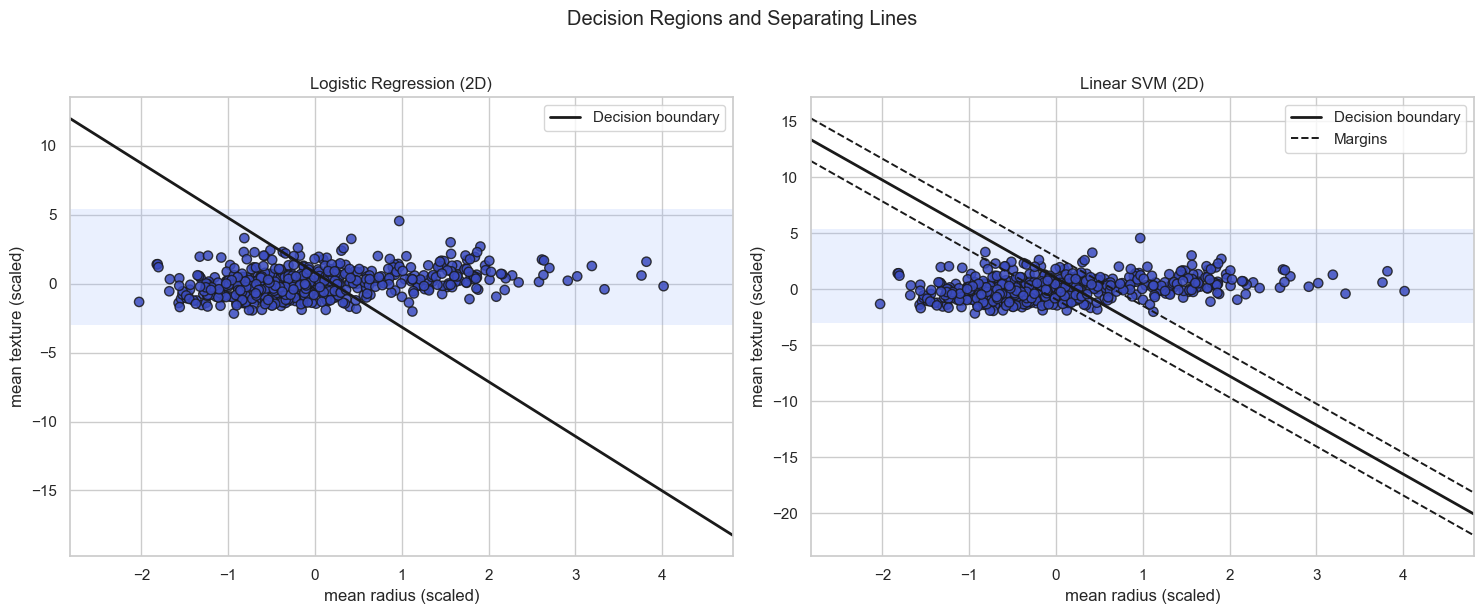

In [15]:
# 2D decision-boundary visualization
# Use two features so the separating line/regions are visible.
feature_pair = ["mean radius", "mean texture"]

X_pair = X[feature_pair].copy()
y_pair = y.copy()

X_pair_train, X_pair_test, y_pair_train, y_pair_test = train_test_split(
    X_pair, y_pair, test_size=0.2, random_state=42, stratify=y_pair
)

pair_imputer = SimpleImputer(strategy="median")
X_pair_train_imp = pair_imputer.fit_transform(X_pair_train)
X_pair_test_imp = pair_imputer.transform(X_pair_test)

pair_scaler = StandardScaler()
X_pair_train_scaled = pair_scaler.fit_transform(X_pair_train_imp)
X_pair_test_scaled = pair_scaler.transform(X_pair_test_imp)

# Fit 2D models used only for visualization
lr_2d = LogisticRegression(max_iter=3000, random_state=42)
svm_2d = SVC(kernel="linear", C=1.0, random_state=42)
lr_2d.fit(X_pair_train_scaled, y_pair_train)
svm_2d.fit(X_pair_train_scaled, y_pair_train)

X_plot = np.vstack([X_pair_train_scaled, X_pair_test_scaled])
y_plot = np.concatenate([y_pair_train, y_pair_test])
y_num = np.where(y_plot == "M", 1, 0)

x_min, x_max = X_plot[:, 0].min() - 0.8, X_plot[:, 0].max() + 0.8
y_min, y_max = X_plot[:, 1].min() - 0.8, X_plot[:, 1].max() + 0.8
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400), np.linspace(y_min, y_max, 400))
grid = np.c_[xx.ravel(), yy.ravel()]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, model, title in [
    (axes[0], lr_2d, "Logistic Regression (2D)"),
    (axes[1], svm_2d, "Linear SVM (2D)"),
]:
    pred = model.predict(grid)
    z = np.where(pred == "M", 1, 0).reshape(xx.shape)

    ax.contourf(xx, yy, z, levels=[-0.5, 0.5, 1.5], cmap="coolwarm", alpha=0.18)
    ax.scatter(
        X_plot[:, 0],
        X_plot[:, 1],
        c=y_num,
        cmap="coolwarm",
        edgecolor="k",
        s=45,
        alpha=0.85,
    )

    # Plot separating line (and margins for SVM)
    w = model.coef_[0]
    b = model.intercept_[0]

    if abs(w[1]) > 1e-8:
        x_vals = np.linspace(x_min, x_max, 200)
        decision_line = -(w[0] * x_vals + b) / w[1]
        ax.plot(x_vals, decision_line, "k-", linewidth=2, label="Decision boundary")

        if title.startswith("Linear SVM"):
            margin_up = -(w[0] * x_vals + b - 1) / w[1]
            margin_down = -(w[0] * x_vals + b + 1) / w[1]
            ax.plot(x_vals, margin_up, "k--", linewidth=1.4, label="Margins")
            ax.plot(x_vals, margin_down, "k--", linewidth=1.4)

    ax.set_title(title)
    ax.set_xlabel(f"{feature_pair[0]} (scaled)")
    ax.set_ylabel(f"{feature_pair[1]} (scaled)")
    ax.legend(loc="upper right")

plt.suptitle("Decision Regions and Separating Lines", y=1.02)
plt.tight_layout()
plt.show()


## Final Comparison

Now we compare all trained models using the same evaluation metrics.


In [16]:
results_df = pd.DataFrame(results).sort_values(by="F1", ascending=False).reset_index(drop=True)
results_df


,Model,Accuracy,Precision,Recall,F1
0,KNN (k=3),0.982456,0.972973,1.000000,0.986301
1,Logistic Regression,0.982456,0.986111,0.986111,0.986111
2,Random Forest,0.947368,0.958333,0.958333,0.958333
3,Decision Tree,0.938596,0.957746,0.944444,0.951049
4,Gaussian Naive Bayes,0.929825,0.944444,0.944444,0.944444


In [ ]:
# Visual comparison
plt.figure(figsize=(10, 5))
plot_df = results_df.melt(id_vars="Model", var_name="Metric", value_name="Score")
sns.barplot(data=plot_df, x="Model", y="Score", hue="Metric", palette="Set2")
plt.ylim(0.8, 1.0)
plt.title("Model Performance Comparison")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


### Wrap-Up

In many practical tabular problems:
- Random Forest is often a strong baseline.
- KNN can work well when scaled features separate classes.
- Naive Bayes is a fast benchmark.

Try changing hyperparameters and test split seed to see how rankings change.


In [ ]:
# Bonus: Linear SVM (full feature space)
svm = SVC(kernel="linear", C=1.0, random_state=42)
print("Linear SVM metrics (Bonus):")
print(evaluate_model("Linear SVM (Bonus)", svm, X_train_scaled, X_test_scaled))


Linear SVM metrics (Bonus):
Model        Linear SVM (Bonus)
Accuracy               0.973684
Precision              0.985915
Recall                 0.972222
F1                     0.979021
dtype: object
